In [2]:
import pandas as pd

df = pd.read_csv(r'C:\Users\HP\Desktop\retailpulse_project\data\processed\cleaned_data.csv')

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [3]:
print(df.columns)

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'TotalPrice'],
      dtype='str')


In [5]:
# Daily Sales Data for Prophet

import pandas as pd

# Load data
df = pd.read_csv(r'C:\Users\HP\Desktop\retailpulse_project\data\processed\cleaned_data.csv')

# Convert InvoiceDate to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Aggregate daily sales
daily_sales = (
    df.groupby(df['InvoiceDate'].dt.date)['TotalPrice']
      .sum()
      .reset_index()
)

# Rename columns for Prophet
daily_sales.columns = ['ds', 'y']

# Convert ds back to datetime
daily_sales['ds'] = pd.to_datetime(daily_sales['ds'])

print(daily_sales.head())
print("\nShape:", daily_sales.shape)

          ds         y
0 2010-12-01  46192.49
1 2010-12-02  47197.57
2 2010-12-03  23876.63
3 2010-12-05  31361.28
4 2010-12-06  31009.33

Shape: (305, 2)


In [6]:
from prophet import Prophet

# Create model
model = Prophet()

# Train model
model.fit(daily_sales)

print("Prophet model trained successfully!")

Importing plotly failed. Interactive plots will not work.
10:14:30 - cmdstanpy - INFO - Chain [1] start processing
10:14:36 - cmdstanpy - INFO - Chain [1] done processing


Prophet model trained successfully!


In [7]:
# 30_days forecast

# Create future dataframe (30 days ahead)
future = model.make_future_dataframe(periods=30)

# Generate forecast
forecast = model.predict(future)

# View forecast
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
330,2012-01-04,56819.703362,38547.483425,74078.724366
331,2012-01-05,64274.069535,46794.341675,82039.440703
332,2012-01-06,56479.514348,37787.841886,72781.698444
333,2012-01-07,68593.997565,49763.574775,86538.302253
334,2012-01-08,43310.882115,25302.929785,61141.061095


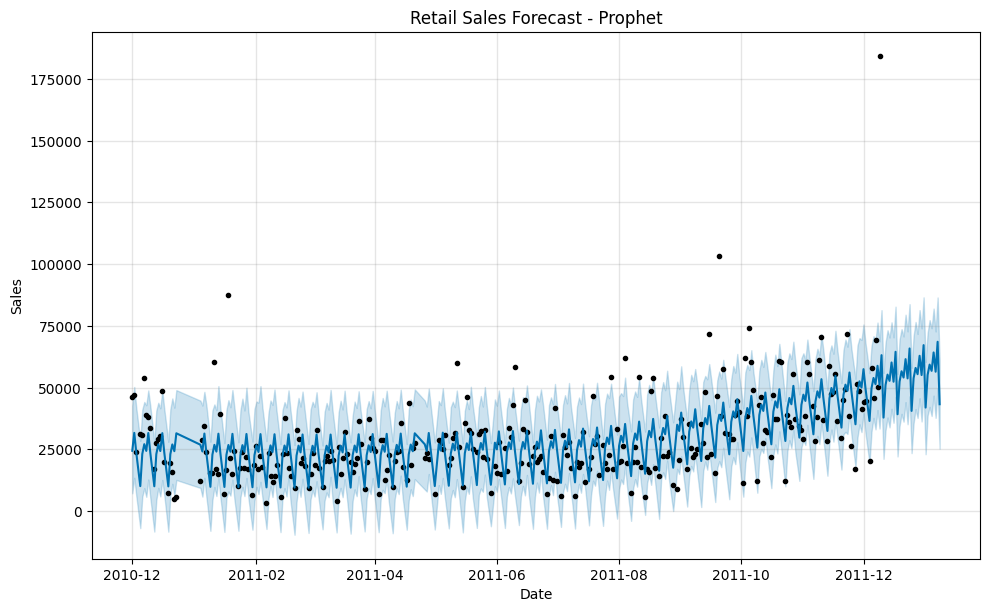

In [9]:
# visualize the forecast

import matplotlib.pyplot as plt

# Plot forecast
fig = model.plot(forecast)

plt.title("Retail Sales Forecast - Prophet")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

FORECAST COMPONENTS ANALYSIS


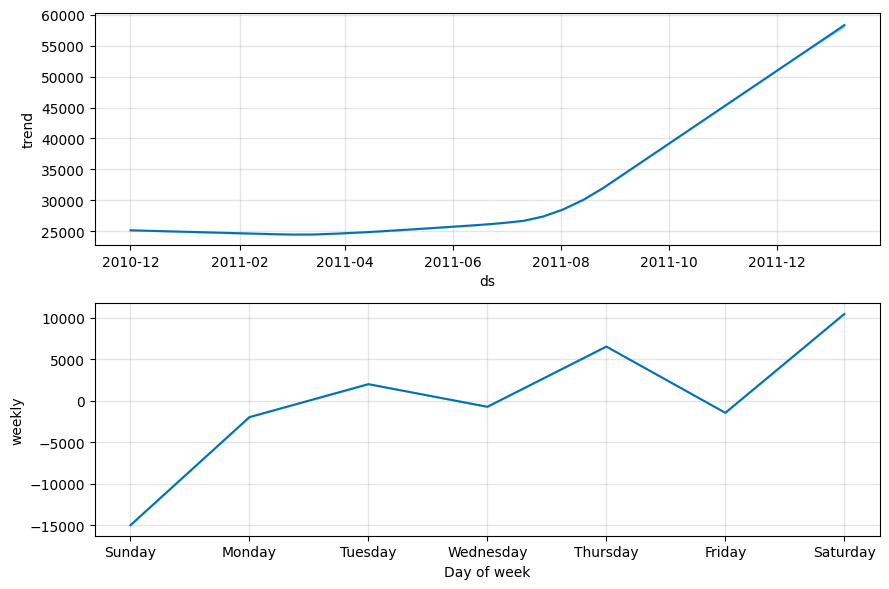

In [11]:

fig2 = model.plot_components(forecast)
plt.show()